In [21]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [22]:
iris = load_iris()
X = iris.data
y = iris.target

model = RandomForestClassifier(n_estimators=100, bootstrap=True, max_samples=0.7, max_features=0.75, random_state=123, oob_score=True)

# Method 1: cross validation
cv_scores = cross_val_score(model, X, y, cv=10)

# Method 2: OOB score
model.fit(X, y)
oob_score = model.oob_score_

print(f"Fold-specific accuracies: {cv_scores}")
print(f"Overall accuracy (cross validation): {cv_scores.mean():.4f}")
print(f"Overall accuracy (OOB): {oob_score:.4f}")

Fold-specific accuracies: [1.         0.93333333 1.         0.93333333 0.93333333 0.93333333
 0.86666667 1.         1.         1.        ]
Overall accuracy (cross validation): 0.9600
Overall accuracy (OOB): 0.9600


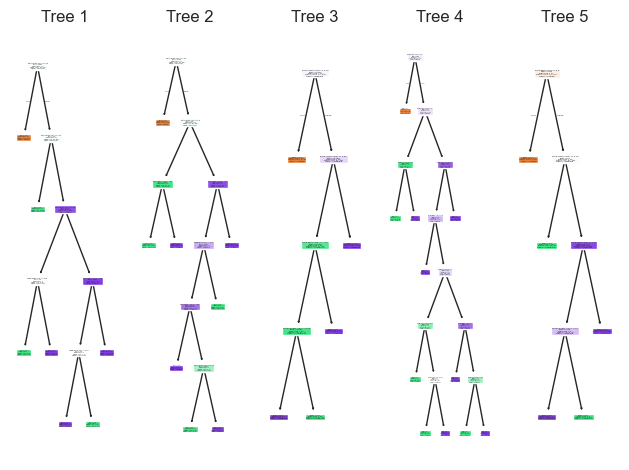

In [23]:
n_trees_to_plot = 5

plt.figure(figure=(20, 10))


for i in range(n_trees_to_plot):
    plt.subplot(1, n_trees_to_plot, i + 1)  # 1 row and n_trees_to_plot columns
    plot_tree(model.estimators_[i], filled=True,
              feature_names=iris.feature_names, class_names=iris.target_names)
    plt.title(f'Tree {i + 1}')

plt.tight_layout()
plt.show()